# (03) table: ex vs. mc vs. st

**Motivation**: Device = ```cuda:1``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, 'PoissonVAE'))
from analysis.eval import sparse_score
from figures.fighelper import *
from main.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

## Fig save dir

In [10]:
fig_dir = pjoin(fig_base_dir, 'nips_may22')
os.makedirs(fig_dir, exist_ok=True)
print(os.listdir(fig_dir))

kws_fig = {
    'transparent': True,
    'bbox_inches': 'tight',
    'dpi': 300,
}

[
    'phi_conv_categorical.png',
    'rate_dist_lca.pdf',
    'phi_lca.png',
    'phi_conv_laplace.png',
    'phi_conv_poisson.png',
    'phi_lin_laplace.png',
    'phi_fista.png',
    'phi_conv_gaussian.png',
    'phi_lin_poisson.png',
    'recons_samples',
    'phi_lin_categorical.png',
    'nelbo_point.pdf',
    'phi_lin_gaussian.png',
    'phi_ista.png',
    'dead_kl_gap.pdf',
    'rate_dist_vae.pdf'
]

## Device

In [11]:
device_idx = 1
device = f'cuda:{device_idx}'

In [19]:
from analysis.stats import ttest
from analysis.final import add_nelbo_diff
from figures.point import nelbo_point

## Load df

In [13]:
df = pjoin(tmp_dir, 'pvae_results', 'df_main.df')
df = pd.read_pickle(df)
df = add_nelbo_diff(df)
df.shape

(150, 9)

In [14]:
df

,dataset,type,enc_type,n_dims,seed,method,active,nelbo,nelbo_diff
60,CIFAR10-PATCHES,gaussian,conv,512,1,exact,0.246094,149.200775,0.012069
61,CIFAR10-PATCHES,gaussian,conv,512,2,exact,0.246094,149.182770,0.000000
62,CIFAR10-PATCHES,gaussian,conv,512,3,exact,0.246094,149.228668,0.030767
63,CIFAR10-PATCHES,gaussian,conv,512,4,exact,0.246094,149.223953,0.027606
64,CIFAR10-PATCHES,gaussian,conv,512,5,exact,0.246094,149.184814,0.001371
...,...,...,...,...,...,...,...,...,...
295,MNIST,poisson,lin,512,1,st,0.230469,44.686920,7.880361
296,MNIST,poisson,lin,512,2,st,0.187500,44.772545,8.087071
297,MNIST,poisson,lin,512,3,st,0.214844,44.738281,8.004354
298,MNIST,poisson,lin,512,4,st,0.197266,44.753235,8.040454


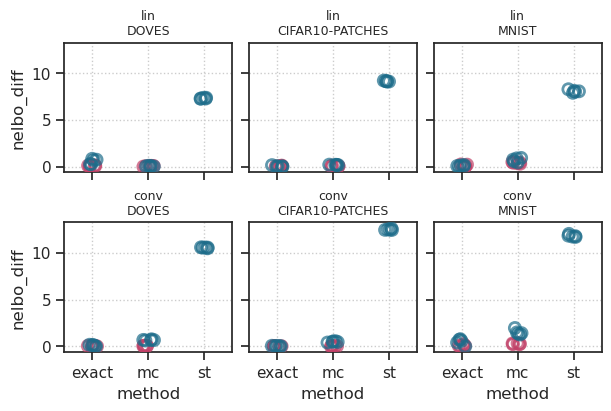

In [17]:
fig, axes = nelbo_point(df, scale=2, remove_lbls=False)
# fig.savefig(pjoin(fig_dir, 'nelbo_point.pdf'), **kws_fig)

In [22]:
group_cols = ['type', 'dataset', 'enc_type', 'method']

df_agg, df_ttest = ttest(
    df=df,
    value='nelbo_diff',
    by=group_cols,
    test_conds=[('exact', 'mc')]
)

In [24]:
from figures.table import table_entry_loss

In [25]:
for model in ['poisson', 'gaussian']:
    table = table_entry_loss(model, df_agg)
    print(f"——— model: {model} ———\n")
    print(table)
    print('\n\n\n')

——— model: poisson ———

\begin{tabularx}{34mm}{CC}
    \entry{0.6}{.5} & \entry{0.1}{.1} \\ 
    \entry{0.0}{.1} & \entry{0.7}{.1} \\ 
    \entry{7.3}{.1} & \entry{10.5}{.1}
\end{tabularx}
&
\begin{tabularx}{34mm}{CC}
    \entry{0.0}{.1} & \entry{0.0}{.0} \\ 
    \entry{0.2}{.0} & \entry{0.5}{.1} \\ 
    \entry{9.1}{.1} & \entry{12.5}{.1}
\end{tabularx}
&
\begin{tabularx}{34mm}{CC}
    \entry{0.1}{.1} & \entry{0.5}{.6} \\ 
    \entry{0.7}{.4} & \entry{1.5}{.5} \\ 
    \entry{8.1}{.3} & \entry{11.8}{.2}
\end{tabularx}

——— model: gaussian ———

\begin{tabularx}{34mm}{CC}
    \entry{0.1}{.1} & \entry{0.0}{.0} \\ 
    \entry{0.1}{.1} & \entry{0.0}{.0}
\end{tabularx}
&
\begin{tabularx}{34mm}{CC}
    \entry{0.0}{.1} & \entry{0.0}{.0} \\ 
    \entry{0.1}{.1} & \entry{0.0}{.0}
\end{tabularx}
&
\begin{tabularx}{34mm}{CC}
    \entry{0.1}{.2} & \entry{0.1}{.2} \\ 
    \entry{0.4}{.1} & \entry{0.3}{.1}
\end{tabularx}

In [28]:
_df = df.loc[df['type'] == 'poisson']
_df.groupby(['enc_type', 'method']).mean(numeric_only=True)

n_dims  seed    active       nelbo  nelbo_diff
enc_type method                                                
conv     exact    512.0   3.0  0.844401  121.416649    0.207681
         mc       512.0   3.0  0.724479  122.112648    0.889266
         st       512.0   3.0  0.758333  135.292282   11.617087
lin      exact    512.0   3.0  0.819401  125.529144    0.226096
         mc       512.0   3.0  0.839974  125.405930    0.309000
         st       512.0   3.0  0.726042  135.443253    8.158747